/tmp/ipykernel_3039/4004497708.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.745709,0.750384,-0.146696,0.161965,17882,20.160772
2,-0.636325,0.928993,-0.066146,0.171283,17660,19.910482
3,-0.603178,1.054167,-0.011277,0.188384,17692,19.946560
4,-0.586549,1.599186,0.058691,0.218730,17660,19.910482
5,-0.534446,4.634305,0.247836,0.376771,17803,20.071705


Returns Analysis


,1D,5D,10D
Ann. alpha,0.355,0.293,0.225
beta,-0.044,-0.021,0.009
Mean Period Wise Return Top Quantile (bps),15.921,11.739,9.707
Mean Period Wise Return Bottom Quantile (bps),-3.336,-7.169,-6.911
Mean Period Wise Spread (bps),19.257,18.405,16.416


<Figure size 640x480 with 0 Axes>

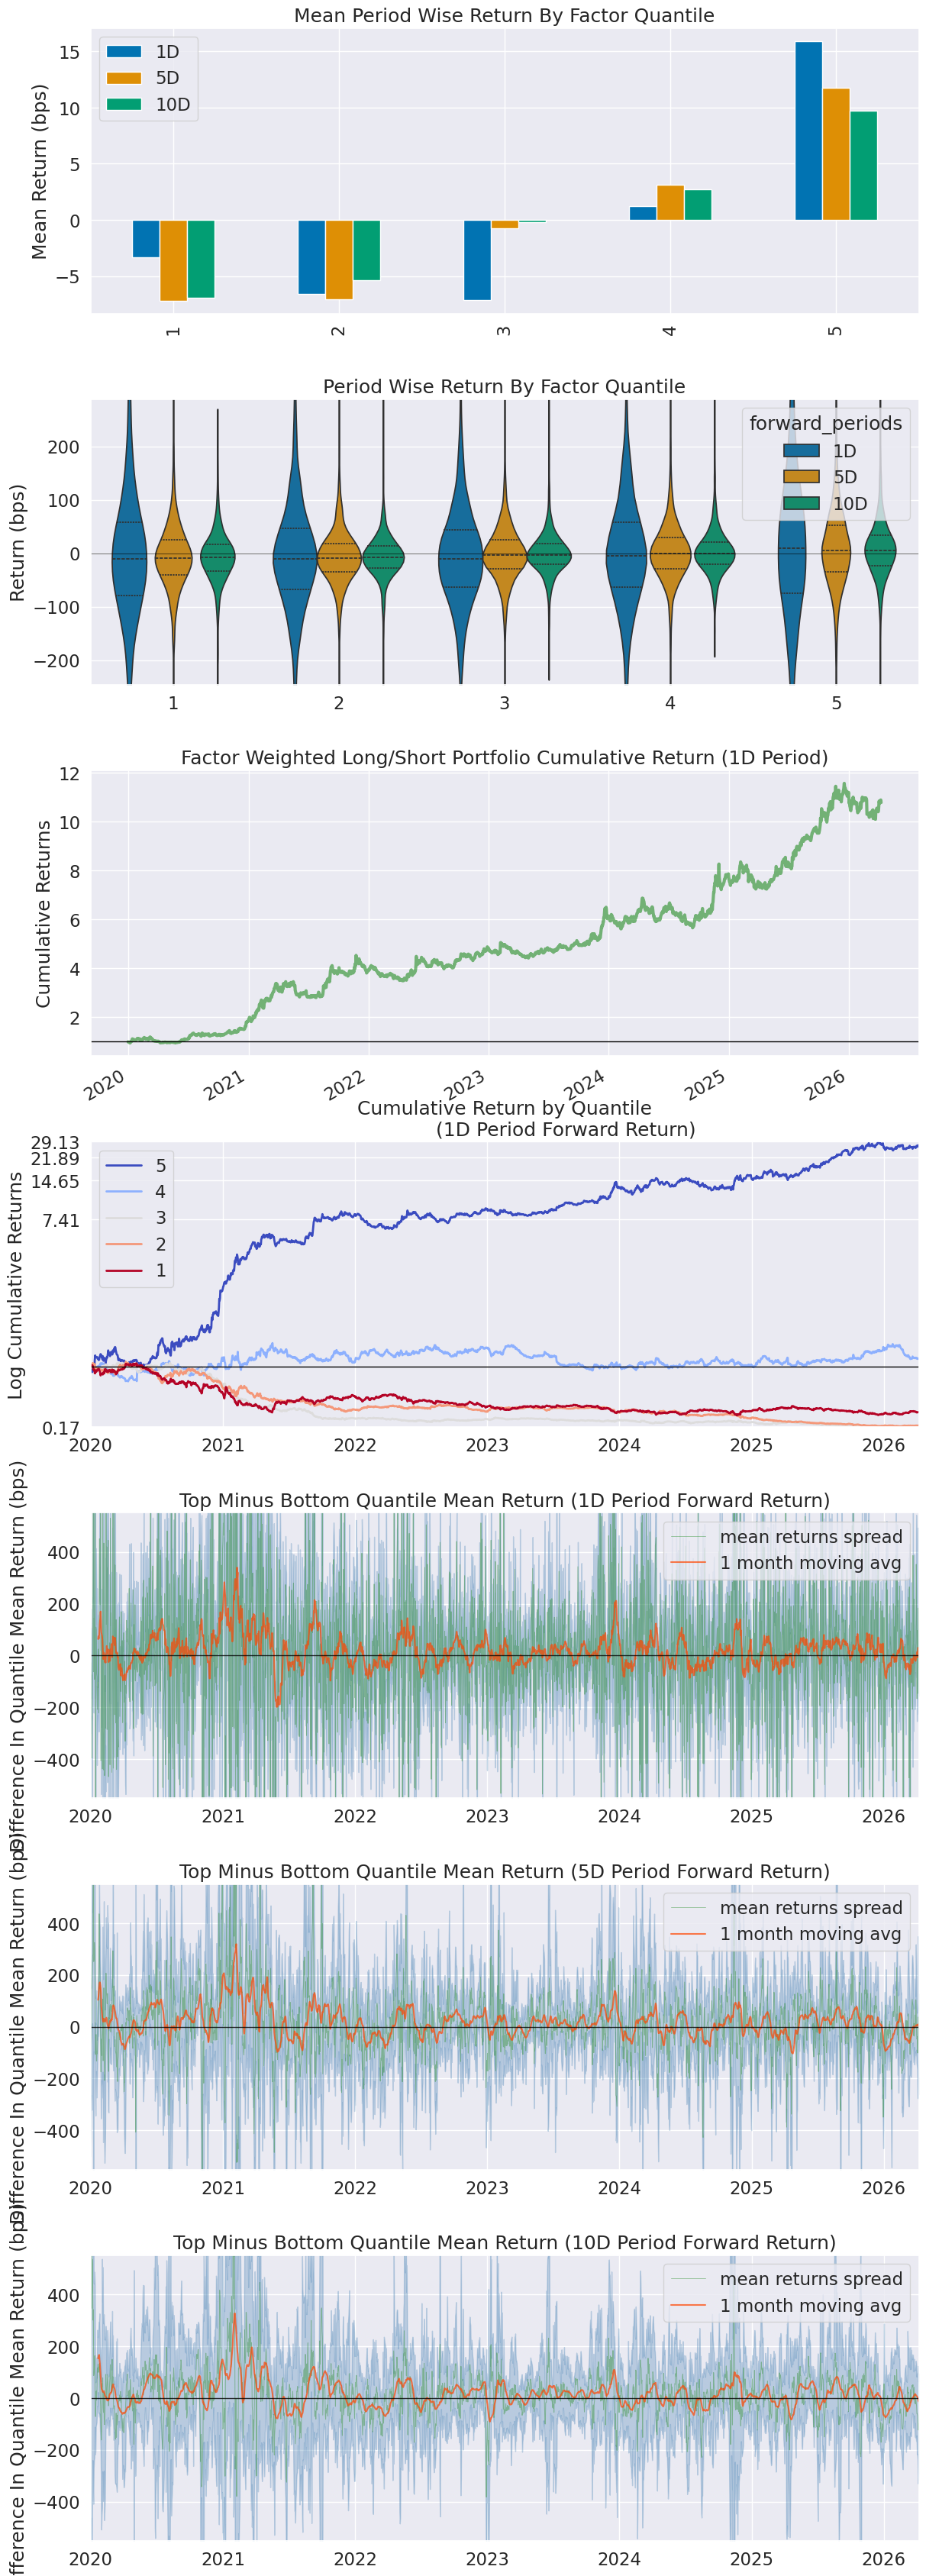

Information Analysis


,1D,5D,10D
IC Mean,-0.006,0.012,0.020
IC Std.,0.258,0.253,0.246
Risk-Adjusted IC,-0.024,0.049,0.083
t-stat(IC),-1.128,2.343,3.981
p-value(IC),0.260,0.019,0.000
IC Skew,0.040,-0.036,-0.107
IC Kurtosis,-0.287,-0.289,-0.328


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


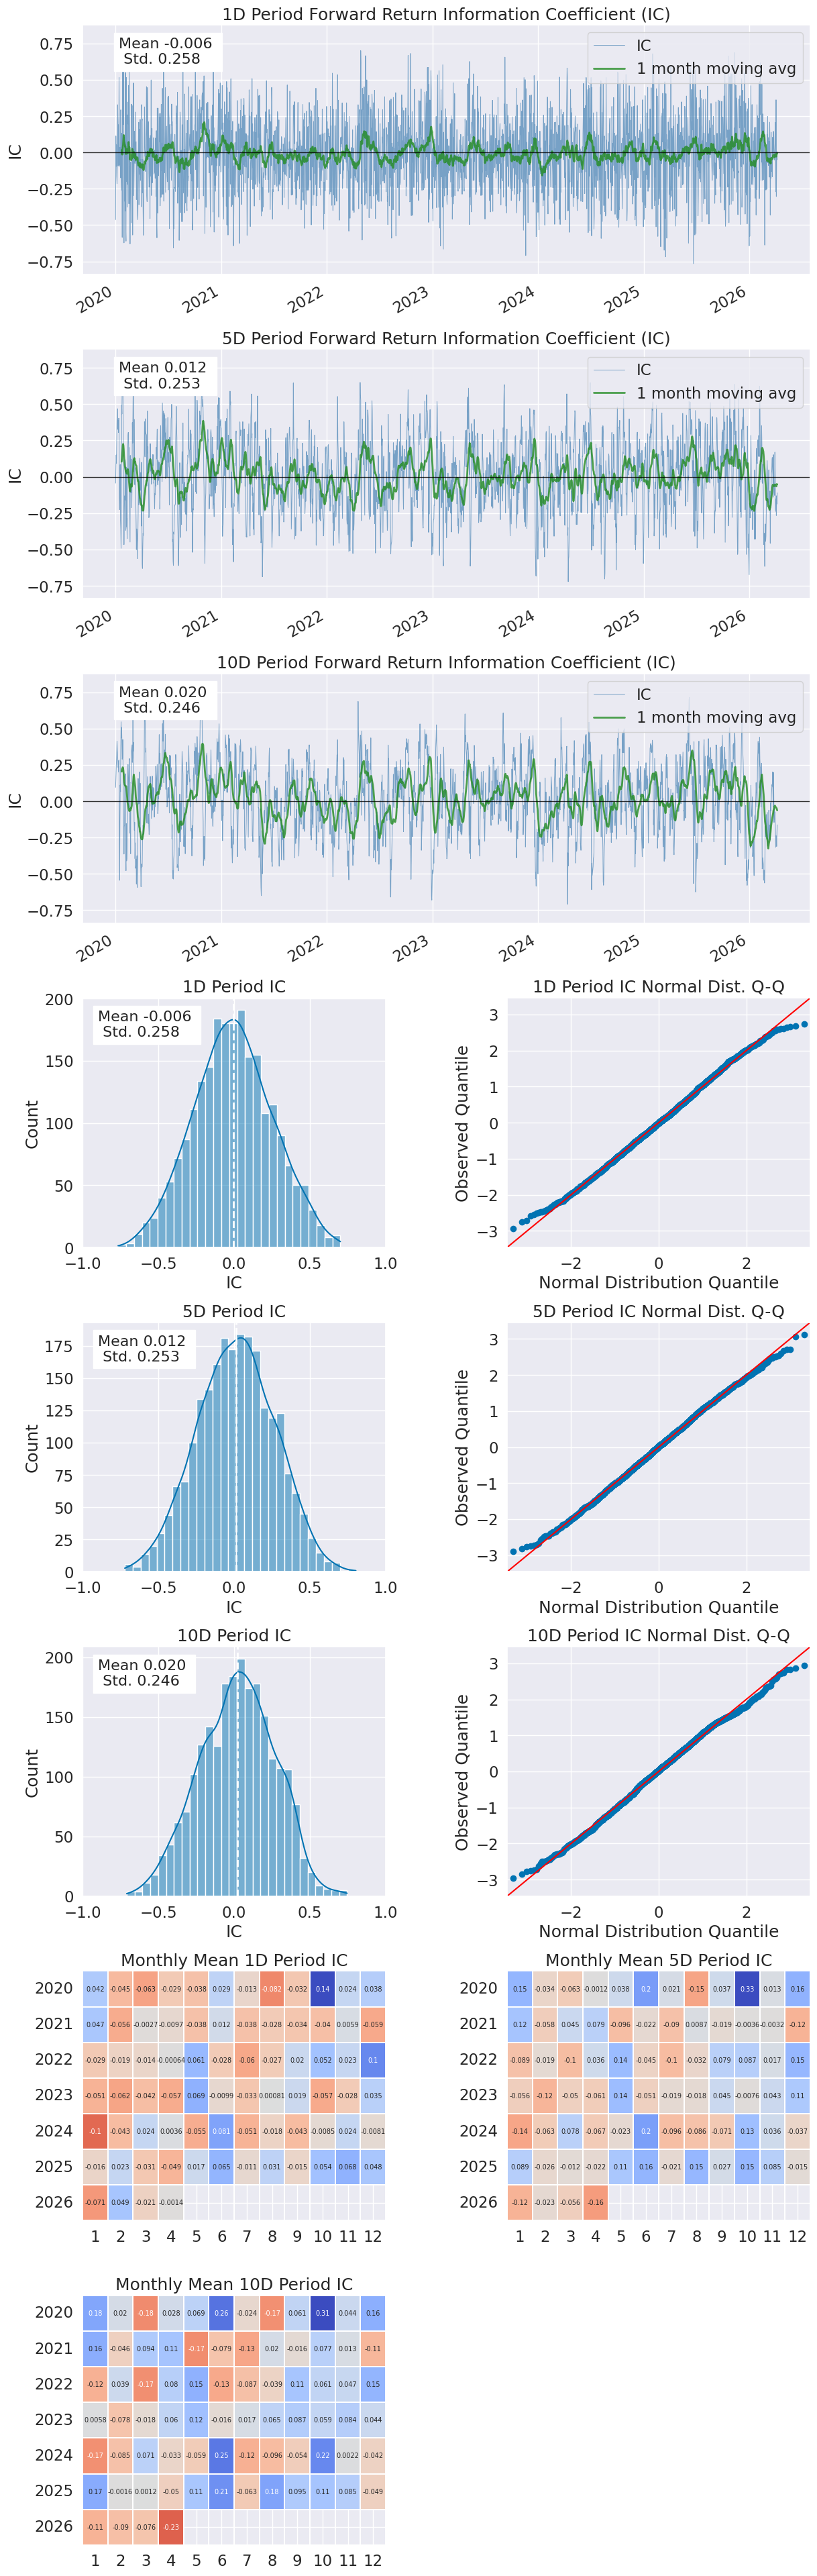

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.192,0.393,0.527
Quantile 2 Mean Turnover,0.379,0.605,0.701
Quantile 3 Mean Turnover,0.408,0.633,0.724
Quantile 4 Mean Turnover,0.349,0.590,0.692
Quantile 5 Mean Turnover,0.172,0.379,0.519


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.943,0.775,0.606


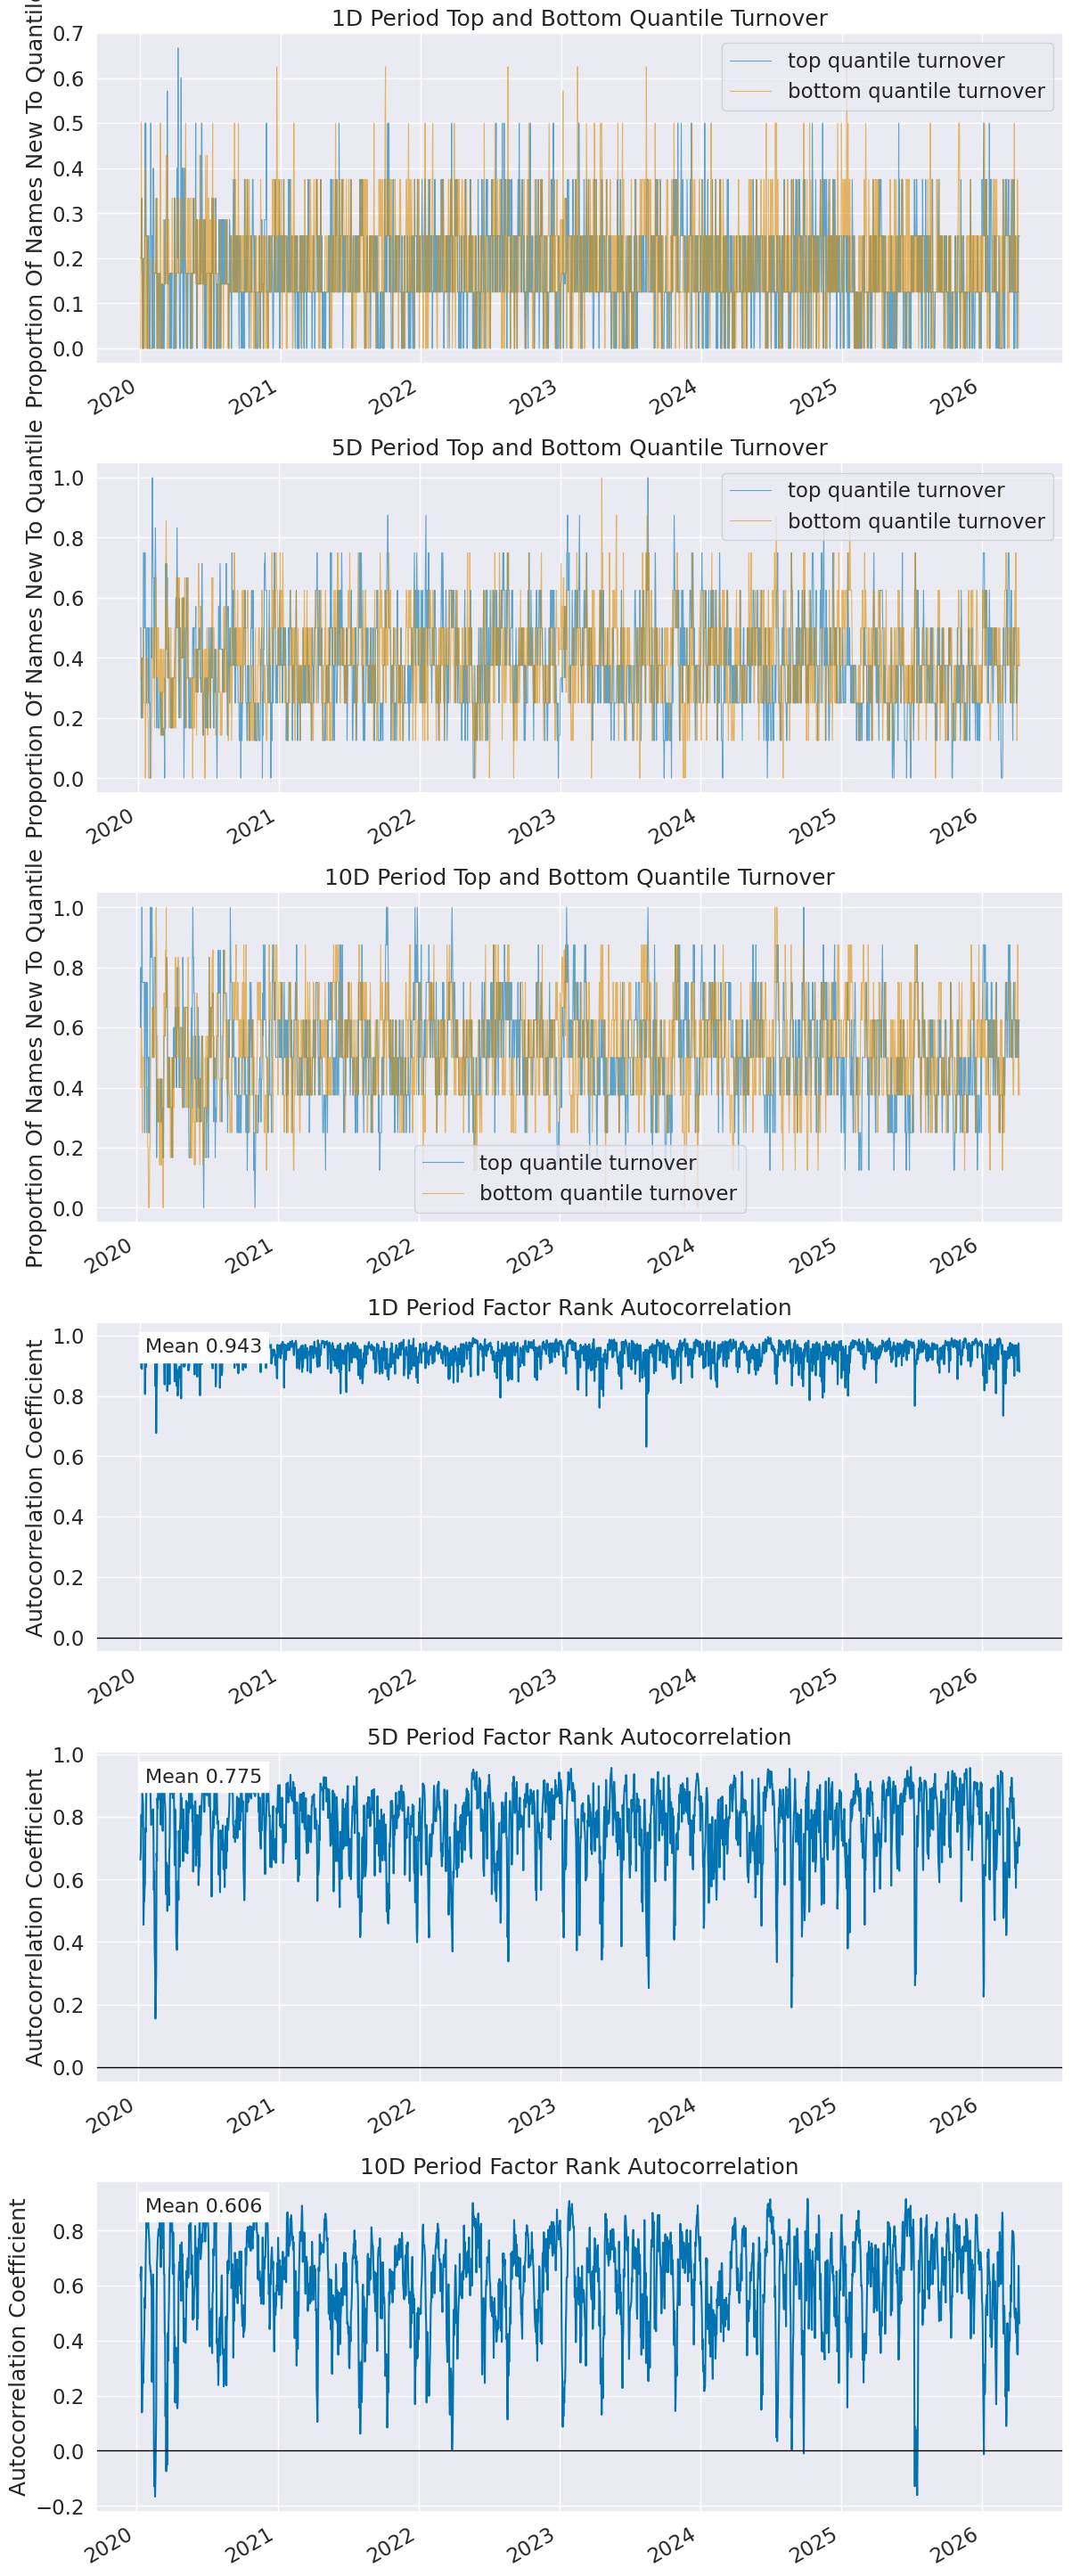

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# factsheet-content/factors.yaml -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Momentum -- portfolio momentum.40
portfolio = "momentum"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)